In [1]:
from phase_map import phase_map
from plot_flare_surfmn import plot_flare_surfmn

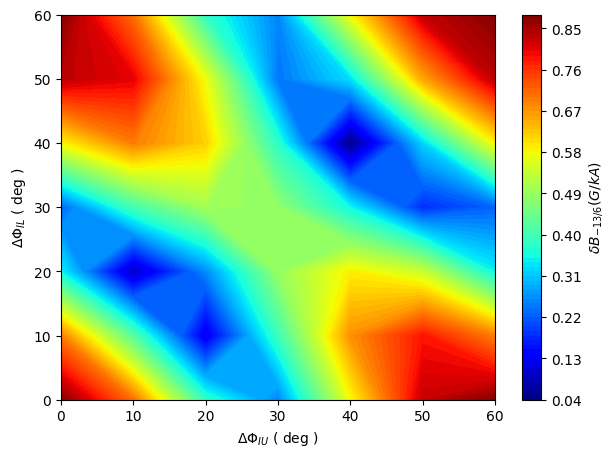

In [13]:
phase_map('/home/jfernandes/phase_map/shot0000/eq000/single_fluid/n06/', n_tor=6, m_pol=-13, d_phase=10)

Loading surfmn data from /home/jfernandes/phase_map/shot0000/eq000/single_fluid/n06/dephase_IL_060_IU_060.npz...
Data loaded successfully.
Plotting...


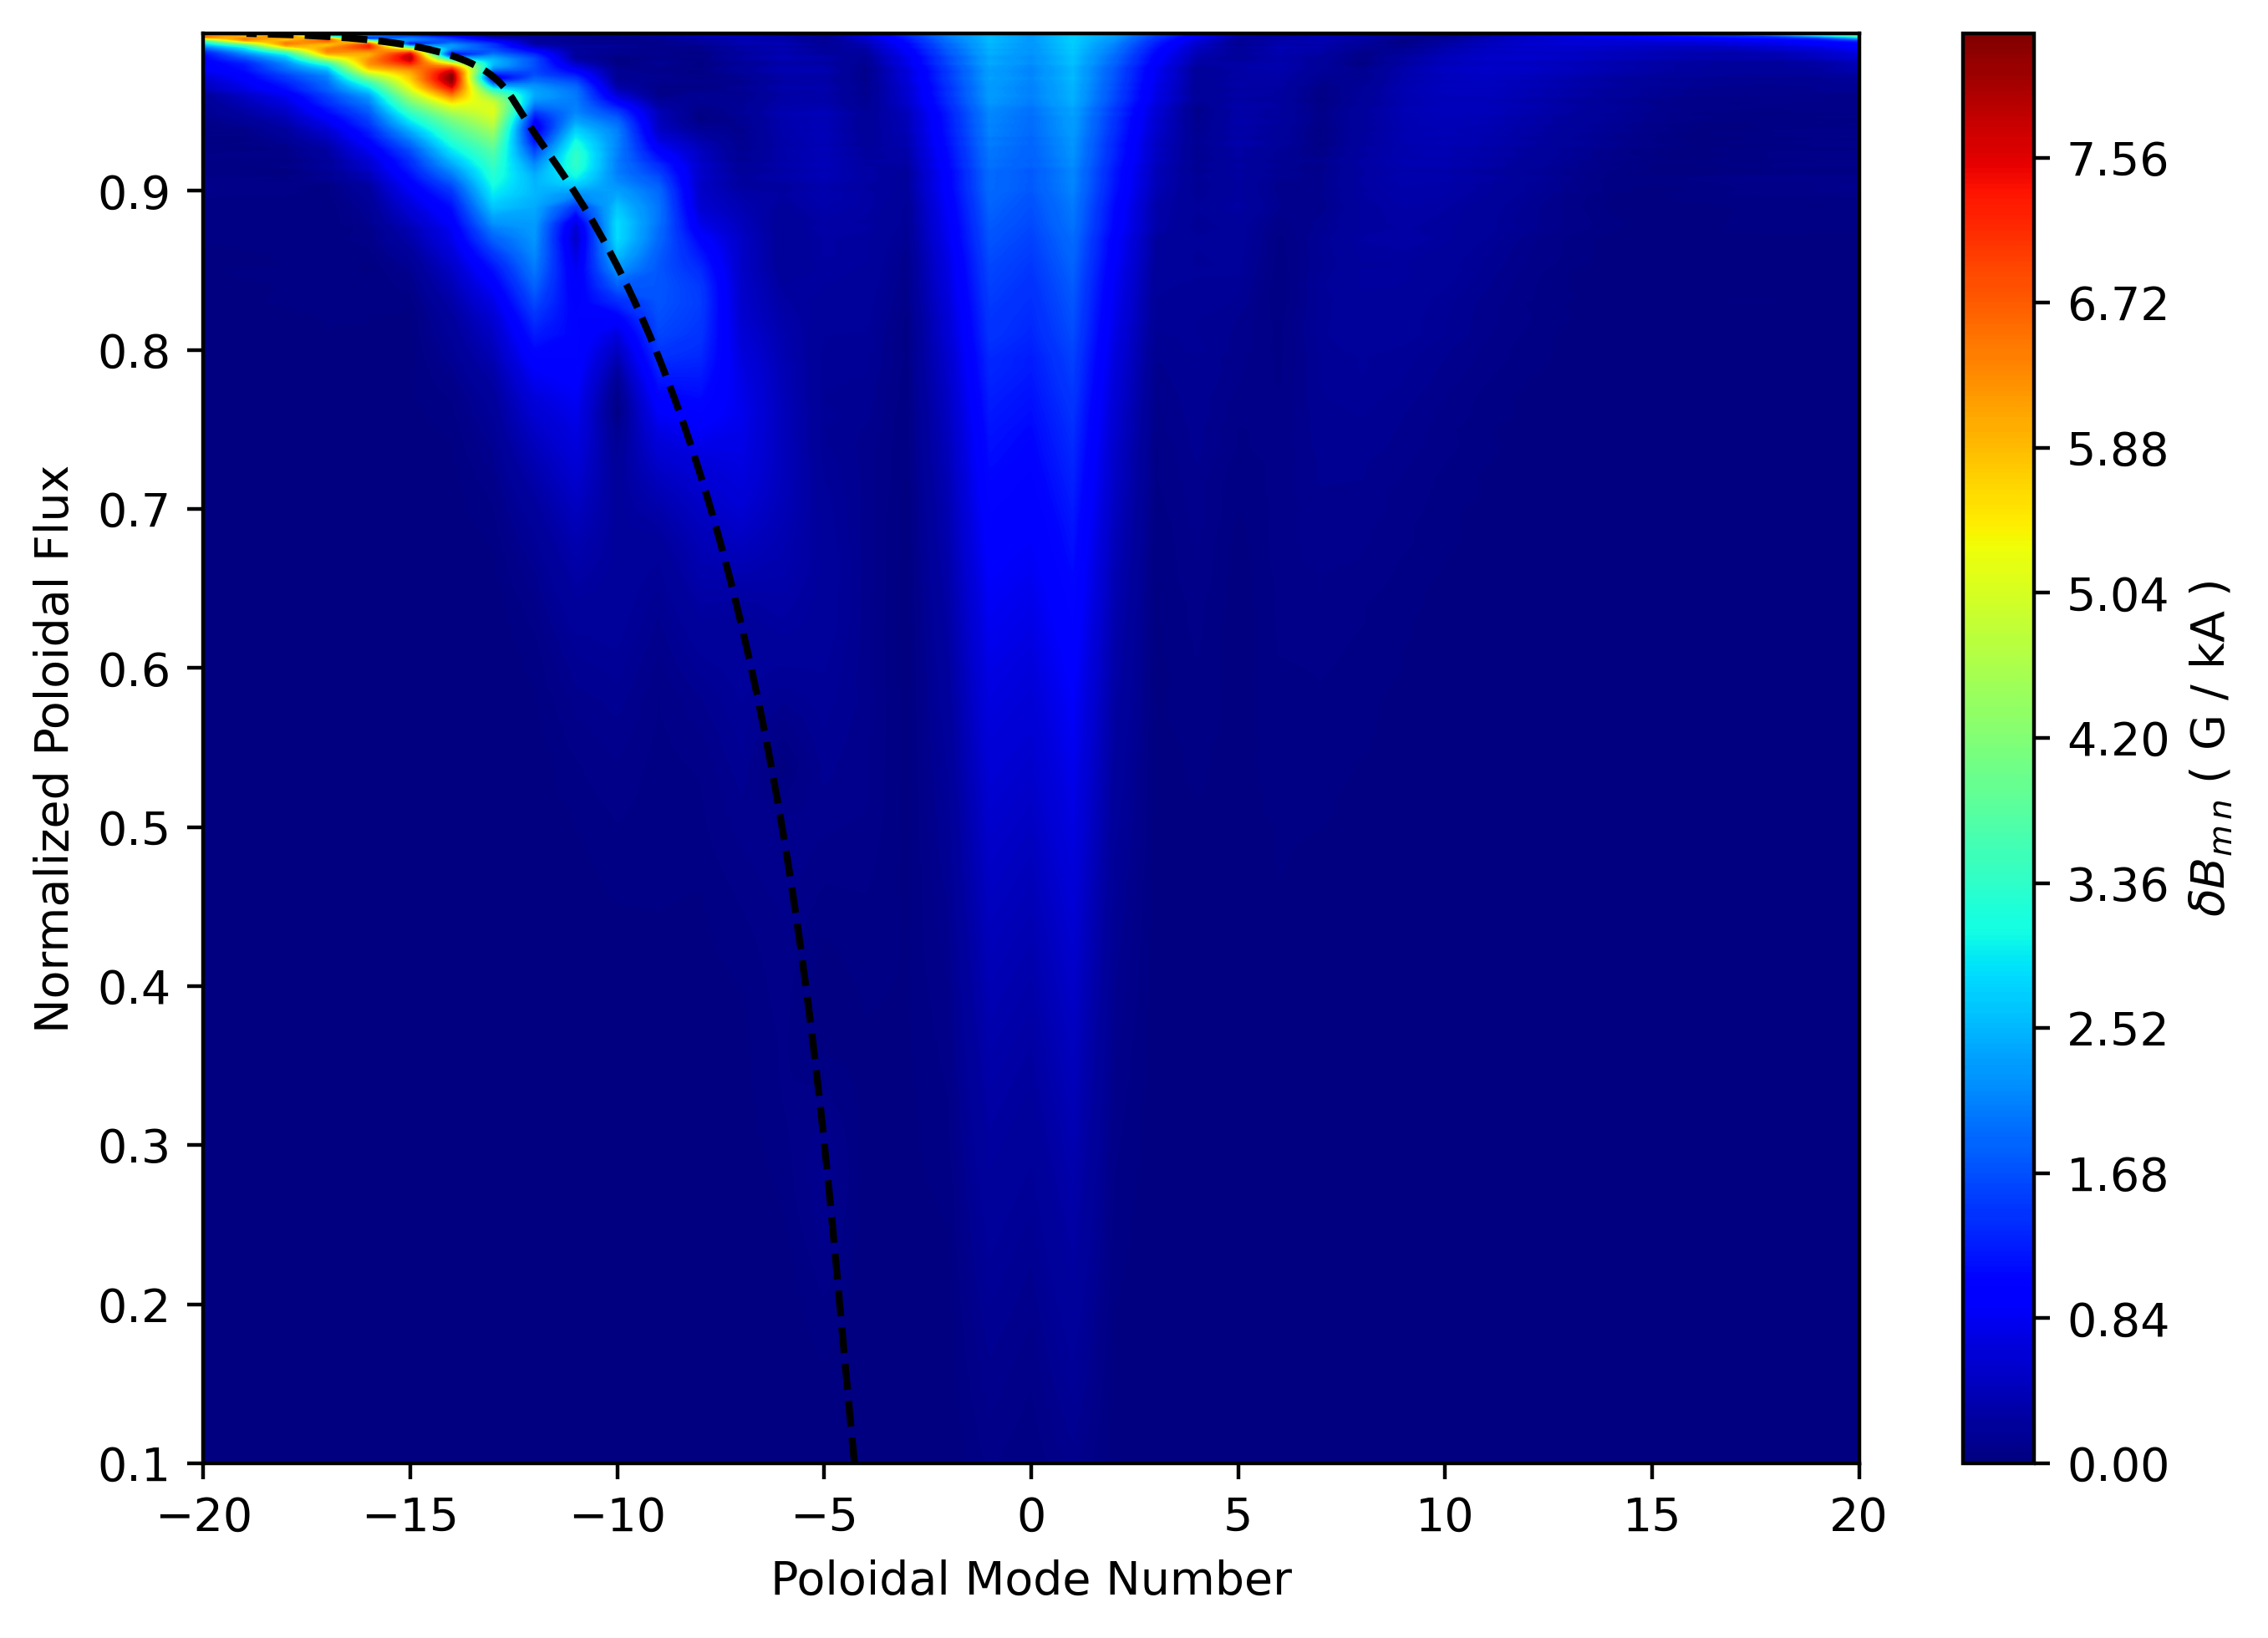

In [17]:
plot_flare_surfmn("/home/jfernandes/phase_map/shot0000/eq000/single_fluid/n06/dephase_IL_060_IU_060.npz", dpi=400, levels=300)

In [1]:
import argparse
import numpy as np
from flare import model
from flare.analysis import equi2d_rzarray, fluxsurf2d_parameters
from flare.analysis import fourier_transform
from scipy.interpolate import CubicSpline

model.load("/home/jfernandes/DATABASE/flare/TCABR/shot0000/eq000/single_fluid/single_coil/n03/dephase_IL_000/dephase_IU_000")


 FLARE - The Field Line Analysis and Reconstruction Engine

 master (2025-07-30 11:33:59 -0500 22afb9)
 Boundary setup (divertor targets, first wall, limiters):

   - A1: /mnt/home/jfernandes/machines_geo/input_geo/tcabr_first_wall.txt
        Number of segments: 49


 Toroidally symmetric (2D) equilibrium:
        Bounding box:               R      =    0.155 m  ->     1.055 m
                                    Z      =   -0.650 m  ->     0.650 m
        Magnetic axis:                   ( 0.631,  -0.001) m
        no X-points defined
        Helicity (toroidal & poloidal field direction):    -  +
        Toroidal magnetic field:  Bt(axis) =   -1.085 T
        Delta Psi                          = -0.11810E-01

 Perturbation field:


period = 6.28318
nperiods = 1
Reading adjacency data.
Max neighbors = 3
period = 6.28318
nperiods = 1
Reading adjacency data.
Max neighbors = 3
period = 6.28318
nperiods = 1
Reading adjacency data.
Max neighbors = 3
period = 6.28318
nperiods = 1
Reading adjacency data.
Max neighbors = 3



- Magnetic field from M3D-C1: C1.h5
        timeslice:    1, amplitude = 1.000, phase = .000 deg

- Magnetic field from M3D-C1: C1.h5
        timeslice:    1, amplitude = 1.000, phase = .000 deg

- Magnetic field from M3D-C1: C1.h5
        timeslice:    1, amplitude = 1.000, phase = .000 deg

- Magnetic field from M3D-C1: C1.h5
        timeslice:    0, amplitude = .000, phase = .000 deg

- Magnetic field from M3D-C1: C1.h5
        timeslice:    0, amplitude = .000, phase = .000 deg

- Magnetic field from M3D-C1: C1.h5
        timeslice:    0, amplitude = .000, phase = .000 deg



period = 6.28318
nperiods = 1
Reading adjacency data.
Max neighbors = 3
period = 6.28318
nperiods = 1
Reading adjacency data.
Max neighbors = 3
period = 6.28318
nperiods = 1
Reading adjacency data.
Max neighbors = 3


In [2]:
n_max = 3
m_max = 5

psiN_val = np.linspace(0.1, 0.9, 81)
psiN_ped = np.linspace(0.901, 1.0, 100) 
psiN_values = np.concatenate((psiN_val, psiN_ped))

theta = 0
rz_array = equi2d_rzarray(psiN_values, theta) # map  psiN to R,Z
R_vals, Z_vals = rz_array[0], rz_array[1]
flux_params = [fluxsurf2d_parameters((R, Z)) for R, Z in zip(R_vals, Z_vals)]
q_vals = np.array([params[0] for params in flux_params])  # extract q values
area_vals = np.array([params[2] for params in flux_params])  # extract area values
q_vals = q_vals[:-1] # remove last element
psiN_values = psiN_values[:-1]
area_vals = area_vals[:-1]

In [3]:
psiN_values

array([0.1  , 0.11 , 0.12 , 0.13 , 0.14 , 0.15 , 0.16 , 0.17 , 0.18 ,
       0.19 , 0.2  , 0.21 , 0.22 , 0.23 , 0.24 , 0.25 , 0.26 , 0.27 ,
       0.28 , 0.29 , 0.3  , 0.31 , 0.32 , 0.33 , 0.34 , 0.35 , 0.36 ,
       0.37 , 0.38 , 0.39 , 0.4  , 0.41 , 0.42 , 0.43 , 0.44 , 0.45 ,
       0.46 , 0.47 , 0.48 , 0.49 , 0.5  , 0.51 , 0.52 , 0.53 , 0.54 ,
       0.55 , 0.56 , 0.57 , 0.58 , 0.59 , 0.6  , 0.61 , 0.62 , 0.63 ,
       0.64 , 0.65 , 0.66 , 0.67 , 0.68 , 0.69 , 0.7  , 0.71 , 0.72 ,
       0.73 , 0.74 , 0.75 , 0.76 , 0.77 , 0.78 , 0.79 , 0.8  , 0.81 ,
       0.82 , 0.83 , 0.84 , 0.85 , 0.86 , 0.87 , 0.88 , 0.89 , 0.9  ,
       0.901, 0.902, 0.903, 0.904, 0.905, 0.906, 0.907, 0.908, 0.909,
       0.91 , 0.911, 0.912, 0.913, 0.914, 0.915, 0.916, 0.917, 0.918,
       0.919, 0.92 , 0.921, 0.922, 0.923, 0.924, 0.925, 0.926, 0.927,
       0.928, 0.929, 0.93 , 0.931, 0.932, 0.933, 0.934, 0.935, 0.936,
       0.937, 0.938, 0.939, 0.94 , 0.941, 0.942, 0.943, 0.944, 0.945,
       0.946, 0.947,

In [4]:
q_vals

array([-0.71158216, -0.71796008, -0.72414415, -0.73017867, -0.73610179,
       -0.74194509, -0.74773462, -0.75349354, -0.7592419 , -0.76499813,
       -0.77077736, -0.77659374, -0.78246016, -0.78838873, -0.7943907 ,
       -0.80047622, -0.80665486, -0.81293591, -0.81932806, -0.82583952,
       -0.83247827, -0.83925213, -0.8461687 , -0.85323532, -0.86045925,
       -0.86784754, -0.87540715, -0.88314511, -0.89106843, -0.89918399,
       -0.90749883, -0.91601978, -0.92475384, -0.93370805, -0.94288964,
       -0.95230596, -0.9619644 , -0.97187239, -0.98203768, -0.99246812,
       -1.00317182, -1.01415711, -1.0254326 , -1.03700729, -1.04889041,
       -1.06109149, -1.0736204 , -1.08648748, -1.09970353, -1.11327991,
       -1.12722854, -1.14156187, -1.15629327, -1.17143681, -1.18700735,
       -1.20302082, -1.21949424, -1.23644588, -1.25389518, -1.27186347,
       -1.29037358, -1.30945033, -1.32912089, -1.34941473, -1.37036437,
       -1.39200561, -1.41437794, -1.4375253 , -1.46149644, -1.48

In [5]:
area_vals

array([0.95417254, 1.00401092, 1.0519122 , 1.09811845, 1.1428266 ,
       1.18619981, 1.22837498, 1.26946853, 1.30958055, 1.34879785,
       1.38719643, 1.42484335, 1.46179803, 1.49811373, 1.53383834,
       1.56901509, 1.60368328, 1.63787888, 1.6716348 , 1.70498134,
       1.73794653, 1.77055643, 1.80283524, 1.83480554, 1.86648855,
       1.89790424, 1.92907143, 1.96000791, 1.99073054, 2.02125535,
       2.05159765, 2.08177209, 2.11179267, 2.14167288, 2.17142568,
       2.20106366, 2.23059893, 2.26004325, 2.28940809, 2.3187046 ,
       2.3479437 , 2.3771361 , 2.40629233, 2.43542272, 2.46453754,
       2.49364688, 2.52276081, 2.55188935, 2.58104247, 2.61023015,
       2.63946242, 2.66874938, 2.69810123, 2.72752832, 2.75704117,
       2.78665045, 2.81636713, 2.84620245, 2.87616802, 2.90627586,
       2.9365384 , 2.96696861, 2.99758011, 3.02838716, 3.05940489,
       3.09064929, 3.12213747, 3.15388763, 3.1859195 , 3.21825422,
       3.25091491, 3.28392679, 3.31731753, 3.35111772, 3.38536

In [6]:
# array of sorted unique rational q values
q_res = np.array([])
for n in range (1, n_max + 1):
    for m in range (-m_max * n, m_max * n + 1):
        if m != 0:
            q_res = np.append(q_res, m / n)

q_res.sort()
q_res = np.unique(q_res)

q_res = q_res[(q_res >= np.min(q_vals)) & (q_res <= np.max(q_vals))]

q_res

array([-3.        , -2.66666667, -2.5       , -2.33333333, -2.        ,
       -1.66666667, -1.5       , -1.33333333, -1.        ])

In [7]:
#if q_vals is negative, invert the order of q_vals, psiN_values and area_vals
if q_vals[-1] < 0:
    q_vals = q_vals[::-1]
    psiN_values = psiN_values[::-1]
    area_vals = area_vals[::-1]

# interpolate the psiN and area values at the rational q values
cs_psi = CubicSpline(q_vals, psiN_values)
psiN_res = cs_psi(q_res)
cs_a = CubicSpline(q_vals, area_vals)
area_res = cs_a(q_res)

In [8]:
psiN_res

array([0.99830992, 0.9949775 , 0.99136874, 0.98500412, 0.93637813,
       0.85269259, 0.79534164, 0.72210173, 0.49706364])

In [9]:
area_res

array([4.05506975, 4.02542406, 4.0010611 , 3.96500501, 3.74776488,
       3.42952369, 3.23565828, 3.0040382 , 2.33936337])

In [10]:
# combine and sort the original and resonant values
psiN = np.concatenate((psiN_values, psiN_res))
q = np.concatenate((q_vals, q_res))
area = np.concatenate((area_vals, area_res))

idx_psiN = np.argsort(psiN)
psiN = psiN[idx_psiN]
q = q[idx_psiN]
area = area[idx_psiN]

In [11]:
psiN

array([0.1       , 0.11      , 0.12      , 0.13      , 0.14      ,
       0.15      , 0.16      , 0.17      , 0.18      , 0.19      ,
       0.2       , 0.21      , 0.22      , 0.23      , 0.24      ,
       0.25      , 0.26      , 0.27      , 0.28      , 0.29      ,
       0.3       , 0.31      , 0.32      , 0.33      , 0.34      ,
       0.35      , 0.36      , 0.37      , 0.38      , 0.39      ,
       0.4       , 0.41      , 0.42      , 0.43      , 0.44      ,
       0.45      , 0.46      , 0.47      , 0.48      , 0.49      ,
       0.49706364, 0.5       , 0.51      , 0.52      , 0.53      ,
       0.54      , 0.55      , 0.56      , 0.57      , 0.58      ,
       0.59      , 0.6       , 0.61      , 0.62      , 0.63      ,
       0.64      , 0.65      , 0.66      , 0.67      , 0.68      ,
       0.69      , 0.7       , 0.71      , 0.72      , 0.72210173,
       0.73      , 0.74      , 0.75      , 0.76      , 0.77      ,
       0.78      , 0.79      , 0.79534164, 0.8       , 0.81   

In [12]:
q

array([-0.71158216, -0.71796008, -0.72414415, -0.73017867, -0.73610179,
       -0.74194509, -0.74773462, -0.75349354, -0.7592419 , -0.76499813,
       -0.77077736, -0.77659374, -0.78246016, -0.78838873, -0.7943907 ,
       -0.80047622, -0.80665486, -0.81293591, -0.81932806, -0.82583952,
       -0.83247827, -0.83925213, -0.8461687 , -0.85323532, -0.86045925,
       -0.86784754, -0.87540715, -0.88314511, -0.89106843, -0.89918399,
       -0.90749883, -0.91601978, -0.92475384, -0.93370805, -0.94288964,
       -0.95230596, -0.9619644 , -0.97187239, -0.98203768, -0.99246812,
       -1.        , -1.00317182, -1.01415711, -1.0254326 , -1.03700729,
       -1.04889041, -1.06109149, -1.0736204 , -1.08648748, -1.09970353,
       -1.11327991, -1.12722854, -1.14156187, -1.15629327, -1.17143681,
       -1.18700735, -1.20302082, -1.21949424, -1.23644588, -1.25389518,
       -1.27186347, -1.29037358, -1.30945033, -1.32912089, -1.33333333,
       -1.34941473, -1.37036437, -1.39200561, -1.41437794, -1.43

In [13]:
area

array([0.95417254, 1.00401092, 1.0519122 , 1.09811845, 1.1428266 ,
       1.18619981, 1.22837498, 1.26946853, 1.30958055, 1.34879785,
       1.38719643, 1.42484335, 1.46179803, 1.49811373, 1.53383834,
       1.56901509, 1.60368328, 1.63787888, 1.6716348 , 1.70498134,
       1.73794653, 1.77055643, 1.80283524, 1.83480554, 1.86648855,
       1.89790424, 1.92907143, 1.96000791, 1.99073054, 2.02125535,
       2.05159765, 2.08177209, 2.11179267, 2.14167288, 2.17142568,
       2.20106366, 2.23059893, 2.26004325, 2.28940809, 2.3187046 ,
       2.33936337, 2.3479437 , 2.3771361 , 2.40629233, 2.43542272,
       2.46453754, 2.49364688, 2.52276081, 2.55188935, 2.58104247,
       2.61023015, 2.63946242, 2.66874938, 2.69810123, 2.72752832,
       2.75704117, 2.78665045, 2.81636713, 2.84620245, 2.87616802,
       2.90627586, 2.9365384 , 2.96696861, 2.99758011, 3.0040382 ,
       3.02838716, 3.05940489, 3.09064929, 3.12213747, 3.15388763,
       3.1859195 , 3.21825422, 3.23565828, 3.25091491, 3.28392